# Imports

In [8]:
%load_ext autoreload
%autoreload 2
import time

import jax
import matplotlib.pyplot as plt
from jax import vmap
from jax.tree_util import Partial
from matplotlib import gridspec

from eci.analysis import SimulationVisualizer
from eci.environment import Environment
from eci.voting_system.plurality import _vote_plurality

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parameters

In [9]:
NUM_VOTERS = 100
NUM_CANDIDATES = 3
NUM_PREFERENCES = 3
NUM_SIMULATIONS = 10

# Environment

In [10]:
# maybe remove some parameters (scneario, round)
env = Environment(
    num_voters=NUM_VOTERS,
    num_candidates=NUM_CANDIDATES,
    num_preferences=NUM_PREFERENCES,
)

Pre-compiling JAX function...
Compilation complete.


# Network

In [ ]:
# extract data from agent
all_mus, all_pis, all_volatilities = env._gather_agent_data()


def create_network(mu, pi, tonic_volatility, network):
    """Prepare network for voting."""
    network.attributes[-1]["preferences"] = {"mean": mu, "precision": pi}
    preferences_idx = [
        network.edges[idx].value_parents[0] for idx in network.input_idxs
    ]
    for idx in preferences_idx:
        network.attributes[idx]["tonic_volatility"] = tonic_volatility
    network.input_data(input_data=env.input_data)

    return network.last_attributes, network.node_trajectories


vmap_create_net = Partial(create_network, network=env.network)
env.last_attributes, env.node_trajectories = vmap(vmap_create_net)(
    all_mus, all_pis, all_volatilities
)

env.preferences_idx = [
    env.network.edges[idx].value_parents[0] for idx in env.network.input_idxs
]

# Simulation

In [12]:
# run one simulation
key = jax.random.PRNGKey(int(time.time()))
sim = env.run_one_simulation(_vote_plurality, key)
sim

{'vote_round_1': Array([1, 0, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1,
        1, 1, 1, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1,
        2, 0, 2, 1, 1, 1, 1, 1, 0, 2, 1, 1, 2, 2, 1, 1, 0, 0, 1, 1, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 0], dtype=int32),
 'softmax_probs_round_1': Array([[0.1408483 , 0.6399917 , 0.21916   ],
        [0.15182127, 0.6408614 , 0.20731728],
        [0.14488442, 0.64060205, 0.21451354],
        [0.14331804, 0.6405464 , 0.21613555],
        [0.14954516, 0.6407708 , 0.20968409],
        [0.1434544 , 0.6405534 , 0.21599223],
        [0.14339003, 0.64055026, 0.21605968],
        [0.14210394, 0.64042807, 0.21746795],
        [0.14914705, 0.6407537 , 0.21009928],
        [0.14566156, 0.64062387, 0.21371461],
        [0.14684221, 0.64066166, 0.21249615],
        [0.14101861, 0.6400924 , 0.21888907],
        [0.14614007, 0.64063835, 0.21322164],
      

In [13]:
# run n simulations
key = jax.random.PRNGKey(int(time.time()))
sim = env.run_n_simulation(_vote_plurality, key, NUM_SIMULATIONS)
sim

{0: {'vote_round_1': Array([2, 2, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 2, 1, 0, 1, 2, 1, 1, 0, 1,
         1, 1, 1, 1, 0, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1, 0,
         1, 1, 0, 0, 1, 2, 1, 1, 0, 1, 2, 2, 0, 1, 2, 1, 2, 2, 0, 1, 0, 0,
         1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2,
         1, 0, 1, 0, 1, 1, 2, 2, 1, 0, 0, 0], dtype=int32),
  'softmax_probs_round_1': Array([[0.1408483 , 0.6399917 , 0.21916   ],
         [0.15182127, 0.6408614 , 0.20731728],
         [0.14488442, 0.64060205, 0.21451354],
         [0.14331804, 0.6405464 , 0.21613555],
         [0.14954516, 0.6407708 , 0.20968409],
         [0.1434544 , 0.6405534 , 0.21599223],
         [0.14339003, 0.64055026, 0.21605968],
         [0.14210394, 0.64042807, 0.21746795],
         [0.14914705, 0.6407537 , 0.21009928],
         [0.14566156, 0.64062387, 0.21371461],
         [0.14684221, 0.64066166, 0.21249615],
         [0.14101861, 0.6400924 , 0.21888907],
         [0.14614007, 0.64063835

# Processing data

In [ ]:
# add a way to add the data for each agent and prepare data for ploting
sim

# Plots

In [48]:
# Create the visualizer instance as before
visualizer = SimulationVisualizer(env, env.datacollector)

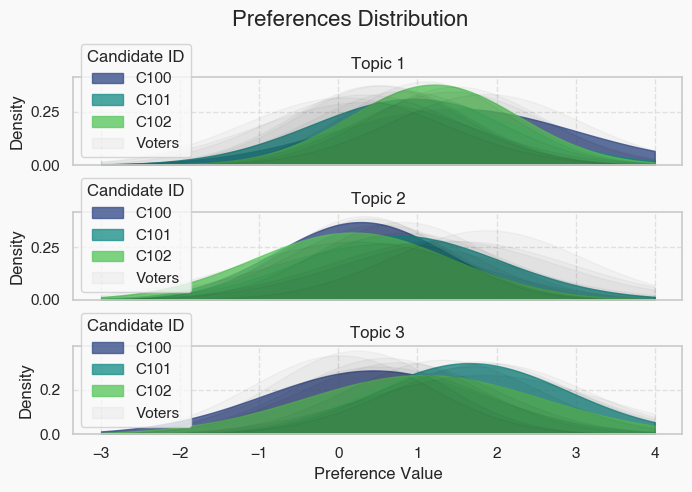

In [49]:
# 2. Create a figure and an array of axes.
fig, axes = plt.subplots(NUM_PREFERENCES, 1, figsize=(7, 5), sharex=True)
fig.suptitle("Preferences Distribution", fontsize=16)
fig, axes = visualizer.plot_preference_distributions(num_voters_to_show=10, axes=axes)
plt.show()
# fig.savefig("fig/distribution.png", dpi=300)

Voter 1 has no trajectory data to plot.


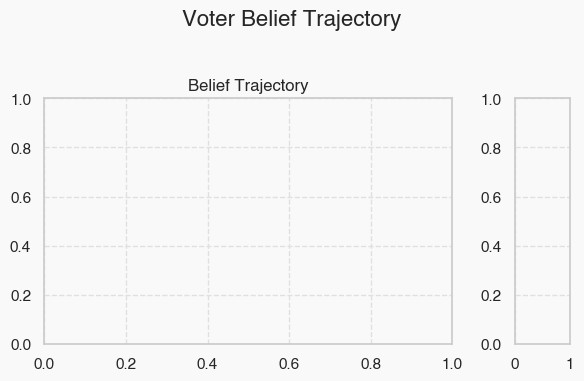

In [50]:
my_fig = plt.figure(figsize=(6, 4))
my_fig.suptitle("Voter Belief Trajectory", fontsize=16)
gs = gridspec.GridSpec(1, 5, figure=my_fig)
axes = my_fig.add_subplot(gs[0, 0:4])
density_ax = my_fig.add_subplot(gs[0, 4], sharey=axes)

# 2. Pass the axes tuple to your function
visualizer.plot_belief_trajectory(voter=env.agents[1], axes=(axes, density_ax))

# 3. You can continue to customize the figure
axes.set_title("Belief Trajectory")  # Override the default title
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout for suptitle
plt.show()
# my_fig.savefig("fig/voter_belief_trajectory.png", dpi=300)

# plot disatisfaction over time

DataFrame is empty or does not contain round data.


NameError: name 'voting_system' is not defined

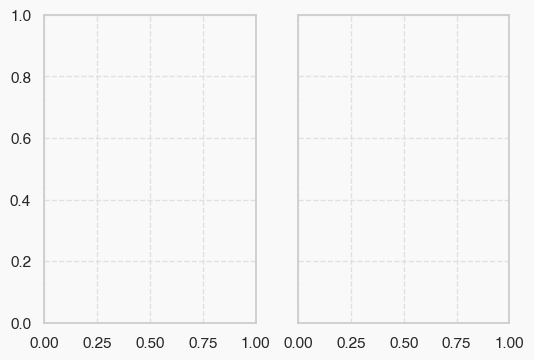

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
visualizer.plot_simulation_results_distribution(plot_kind="d", axes=axes)
# set titles for the entire figure and individual subplots
fig.suptitle(
    "Results Distribution)",
    fontsize=16,
)
axes[0].set_xlabel("Proportion of Votes (1st Round)")
axes[1].set_xlabel("Proportion of Votes (2nd Round)")
plt.tight_layout()
plt.show()
# fig.savefig(f"fig/{voting_system.name}_simulation_results_distribution.png", dpi=300)

NameError: name 'voting_system' is not defined

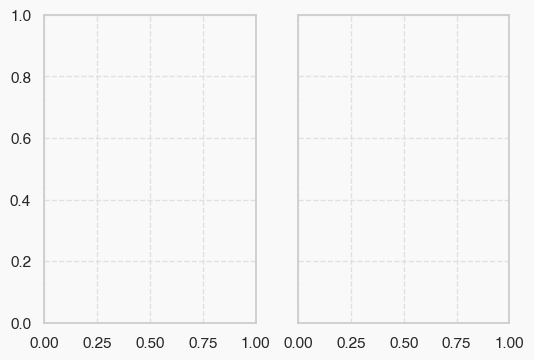

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
fig.suptitle(
    "Results Distribution)",
    fontsize=16,
)
# y limits
# bins de la même taille
visualizer.plot_simulation_results_distribution(axes=axes)
axes[0].set_ylim(0, 80)
axes[1].set_ylim(0, 80)
axes[0].set_xlabel("Proportion of Votes (1st Round)")
axes[1].set_xlabel("Proportion of Votes (2nd Round)")
plt.show()
# fig.savefig(f"fig/{voting_system.name}_simulation_results_histogram.png", dpi=300)